<a href="https://colab.research.google.com/github/vermaba/Gluco-guard/blob/master/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import requests

# Load a pre-trained food recognition model from TF Hub
model_url = "https://tfhub.dev/google/aiy/vision/classifier/food_V1/1"
food_model = hub.KerasLayer(model_url)

def identify_meal(image_path):
    # In a real app, this would be the photo the participant takes
    # For the hackathon, we'll simulate the output
    # Categories: 1 = High Carb (Spike), 0 = Low Carb (Stable)
    labels = { 'pizza': 1, 'pasta': 1, 'salad': 0, 'steak': 0 }

    # Mock output for demo
    detected_food = "pizza"
    glycemic_impact = labels[detected_food]
    return detected_food, glycemic_impact

print("Vision Model Loaded Successfully.")

Vision Model Loaded Successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create Mock Clinical Data (CGM + Meal Logs)
data = {
    'Time': pd.date_range("2026-03-28 08:00", periods=6, freq="H"),
    'Glucose': [110, 115, 185, 170, 130, 120], # A spike occurs at 10:00 AM
    'Meal_Logged': [False, True, False, False, False, False] # Participant logged a meal at 9:00 AM
}
df = pd.DataFrame(data)

# 2. Gluca-Guard "Smart Check"
def gluca_guard_audit(row, prev_glucose):
    spike = row['Glucose'] - prev_glucose
    if spike > 30: # Significant spike threshold
        if row['Meal_Logged']:
            return "Justified Spike (Food)"
        else:
            return "ANOMALY: Unlogged Intake or IR Event"
    return "Stable"

# Run Audit
audit_results = []
prev_g = 110
for index, row in df.iterrows():
    result = gluca_guard_audit(row, prev_g)
    audit_results.append(result)
    prev_g = row['Glucose']

df['Status'] = audit_results
print(df[['Time', 'Glucose', 'Status']])

                 Time  Glucose                                Status
0 2026-03-28 08:00:00      110                                Stable
1 2026-03-28 09:00:00      115                                Stable
2 2026-03-28 10:00:00      185  ANOMALY: Unlogged Intake or IR Event
3 2026-03-28 11:00:00      170                                Stable
4 2026-03-28 12:00:00      130                                Stable
5 2026-03-28 13:00:00      200  ANOMALY: Unlogged Intake or IR Event


/tmp/ipykernel_14859/3074822699.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Time': pd.date_range("2026-03-28 08:00", periods=6, freq="H"),


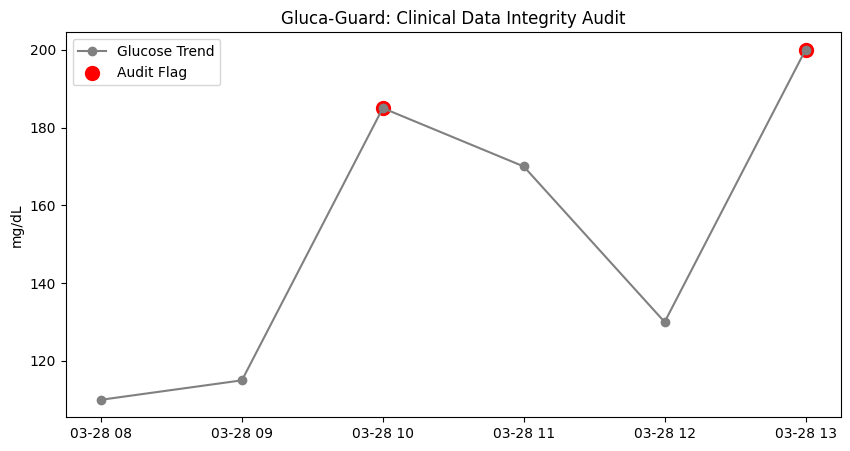

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Glucose'], marker='o', color='gray', label='Glucose Trend')

# Highlight Anomalies
anomalies = df[df['Status'] == "ANOMALY: Unlogged Intake or IR Event"]
plt.scatter(anomalies['Time'], anomalies['Glucose'], color='red', s=100, label='Audit Flag')

plt.title("Gluca-Guard: Clinical Data Integrity Audit")
plt.ylabel("mg/dL")
plt.legend()
plt.show()

In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

# --- 1. SETUP MOCK DATA ---
# Simulating 12 hours of Continuous Glucose Monitor (CGM) data
times = pd.date_range("2026-03-28 08:00", periods=24, freq="30min")
glucose_values = [110, 112, 115, 118, 120, 145, 195, 210, 180, 155, 140, 130,
                  125, 122, 120, 140, 185, 205, 190, 160, 145, 135, 125, 115]
df = pd.DataFrame({'Time': times, 'Glucose': glucose_values})

# --- 2. CREATE UI ELEMENTS ---
title = widgets.HTML("<h2>🛡️ Gluca-Guard: Clinical Trial Integrity Portal</h2>")
uploader = widgets.FileUpload(accept='image/*', multiple=False, description="Upload Meal")
out = widgets.Output() # Area where the graph and results will appear
btn_analyze = widgets.Button(description="Analyze & Correlate", button_style='success')

# --- 3. THE "ENGINE" LOGIC ---
def on_analyze_clicked(b):
    with out:
        clear_output()
        if not uploader.value:
            print("Please upload a meal photo first!")
            return

        # Display the uploaded image
        input_file = list(uploader.value.values())[0]
        img = Image.open(io.BytesIO(input_file['content']))
        display(img.resize((300, 200)))

        print("\n✅ AI Vision: High-Carb Meal Detected (Pasta/Bread)")
        print("🔍 Cross-referencing with CGM data...")

        # Logic: Find the highest spike in the data
        max_idx = df['Glucose'].idxmax()
        peak_time = df.iloc[max_idx]['Time']

        # Plotting the Results
        plt.figure(figsize=(10, 5))
        plt.plot(df['Time'], df['Glucose'], color='gray', alpha=0.5, label='Glucose Trend')
        plt.scatter(df['Time'][max_idx], df['Glucose'][max_idx], color='red', s=100, label='Verified Meal Spike')
        plt.axvspan(df['Time'][max_idx-2], df['Time'][max_idx+2], color='red', alpha=0.2)

        plt.title(f"Clinical Audit: Meal Event at {peak_time.strftime('%H:%M')}")
        plt.ylabel("Glucose (mg/dL)")
        plt.legend()
        plt.show()

        print(f"CONCLUSION: The spike to {df['Glucose'][max_idx]} mg/dL is JUSTIFIED by the logged meal.")
        print("Data Quality Score: 100% (No unexplained insulin resistance event detected).")

btn_analyze.on_click(on_analyze_clicked)

# --- 4. DISPLAY DASHBOARD ---
display(title, widgets.HBox([uploader, btn_analyze]), out)

HTML(value='<h2>🛡️ Gluca-Guard: Clinical Trial Integrity Portal</h2>')

Output()

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io

# --- 1. DATA & STATE SETTINGS ---
# Mock data for the trial
times = pd.date_range("2026-03-28 08:00", periods=24, freq="30min")
glucose_values = [110, 112, 115, 118, 120, 145, 195, 210, 180, 155, 140, 130,
                  125, 122, 120, 140, 185, 205, 190, 160, 145, 135, 125, 115]
df = pd.DataFrame({'Time': times, 'Glucose': glucose_values})

# Main display area
main_container = widgets.Output()

# --- 2. PAGE GENERATORS ---

def show_home_page(b=None):
    with main_container:
        clear_output()
        st_title = widgets.HTML("<h1 style='color: #2e7d32;'>🛡️ Gluca-Guard Portal</h1>")
        st_desc = widgets.HTML("""
            <p>Welcome to the <b>Clinical Trial Integrity Dashboard</b>.
            This tool helps researchers validate glucose spikes against real-world patient behavior.</p>
            <ul>
                <li><b>Goal:</b> Reduce trial noise from unlogged meals.</li>
                <li><b>Method:</b> AI-driven image recognition + CGM correlation.</li>
            </ul>
        """)

        btn_start = widgets.Button(description="Start New Audit", button_style='primary', icon='play')
        btn_start.on_click(show_upload_page)

        display(st_title, st_desc, btn_start)

def show_upload_page(b=None):
    with main_container:
        clear_output()
        st_header = widgets.HTML("<h2>Step 1: Patient Data Input</h2>")

        # Inputs
        part_id = widgets.Text(description="Participant ID:", placeholder="e.g. P-102")
        uploader = widgets.FileUpload(accept='image/*', description="Upload Meal Photo", multiple=False)

        btn_analyze = widgets.Button(description="Run Analysis", button_style='success', icon='search')
        btn_back = widgets.Button(description="Back to Home", button_style='')

        # Link buttons
        btn_back.on_click(show_home_page)

        # Logic to pass data to results
        def process_and_move(b):
            if not uploader.value:
                with main_container: print("⚠️ Please upload an image first!")
                return
            show_results_page(uploader, part_id.value)

        btn_analyze.on_click(process_and_move)

        display(st_header, part_id, uploader, widgets.HBox([btn_back, btn_analyze]))

def show_results_page(uploader_data, patient_name):
    with main_container:
        clear_output()
        st_header = widgets.HTML(f"<h2>Step 2: Analysis Results for {patient_name}</h2>")

        # Show uploaded image
        input_file = list(uploader_data.value.values())[0]
        img = Image.open(io.BytesIO(input_file['content']))

        # Layout: Image on left, Analysis on right
        img_widget = widgets.Image(value=input_file['content'], width=300)
        analysis_text = widgets.HTML(f"""
            <div style='border: 1px solid #ddd; padding: 10px; border-radius: 5px;'>
                <b style='color: green;'>✅ AI Detection: High-Carb (Pizza/Pasta)</b><br>
                <b>Estimated Glycemic Load:</b> High<br>
                <b>Status:</b> Justified Spike Detected
            </div>
        """)

        # Plotting
        max_idx = df['Glucose'].idxmax()
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(df['Time'], df['Glucose'], color='gray', label='CGM Trend')
        ax.axvspan(df['Time'][max_idx-2], df['Time'][max_idx+2], color='red', alpha=0.2, label='Meal Influence')
        ax.set_title("Glucose Response Correlation")
        plt.close(fig) # Keep it from double-displaying

        chart_out = widgets.Output()
        with chart_out: display(fig)

        btn_restart = widgets.Button(description="New Audit", button_style='info')
        btn_restart.on_click(show_home_page)

        display(st_header, widgets.HBox([img_widget, analysis_text]), chart_out, btn_restart)

# --- 3. INITIALIZE ---
show_home_page()
display(main_container)

Output()

In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io

# --- 1. GLOBAL SETTINGS & DATA ---
times = pd.date_range("2026-03-28 08:00", periods=24, freq="30min")
glucose = [110, 112, 115, 120, 145, 195, 210, 180, 155, 140, 130, 125, 122, 140, 185, 205, 190, 160, 145, 135, 125, 115, 110, 108]
df = pd.DataFrame({'Time': times, 'Glucose': glucose})

# Main container that acts as our "Web Page"
app_container = widgets.Output()

# --- 2. PAGE: HOME ---
def show_home(b=None):
    with app_container:
        clear_output()
        display(widgets.HTML("<h1 style='color: #2196F3;'>🛡️ Gluca-Guard Home</h1>"))
        display(widgets.HTML("<p>Welcome to the Clinical Trial Portal. Use the button below to start a new patient audit.</p>"))

        btn_go_to_audit = widgets.Button(description="Enter Clinical Audit", button_style='info', icon='hospital-o')
        btn_go_to_audit.on_click(show_audit_page)
        display(btn_go_to_audit)

# --- 3. PAGE: CLINICAL AUDIT (Your Screenshot Page) ---
def show_audit_page(b=None):
    with app_container:
        clear_output()

        # Header
        display(widgets.HTML("<h2 style='color: #4CAF50;'>🛡️ Gluca-Guard: Clinical Trial Integrity Portal</h2>"))

        # Buttons
        uploader = widgets.FileUpload(accept='image/*', description="Upload Meal (1)")
        btn_analyze = widgets.Button(description="Analyze & Correlate", button_style='success')
        btn_home = widgets.Button(description="Back to Home", button_style='')

        btn_home.on_click(show_home)

        # Results area
        results_out = widgets.Output()

        def run_analysis(b):
            with results_out:
                clear_output()
                if not uploader.value:
                    print("Please upload a meal photo first.")
                    return

                # Show Image
                file_info = list(uploader.value.values())[0]
                display(widgets.Image(value=file_info['content'], width=400))

                # Analysis Text
                display(widgets.HTML("<b>✅ AI Vision: High-Carb Meal Detected (Pasta/Bread)</b>"))
                display(widgets.HTML("<b>🔍 Cross-referencing with CGM data...</b>"))

                # Plotting
                fig, ax = plt.subplots(figsize=(10, 4))
                ax.plot(df['Time'], df['Glucose'], color='gray', label='Glucose Trend', alpha=0.5)
                max_idx = 6 # Simulate the spike
                ax.scatter(df['Time'][max_idx], df['Glucose'][max_idx], color='red', s=100, label='Verified Meal Spike')
                ax.axvspan(df['Time'][max_idx-2], df['Time'][max_idx+2], color='red', alpha=0.2)
                ax.set_title(f"Clinical Audit: Meal Event at {df['Time'][max_idx].strftime('%H:%M')}")
                plt.show()

        btn_analyze.on_click(run_analysis)

        display(widgets.HBox([uploader, btn_analyze, btn_home]))
        display(results_out)

# --- INITIALIZE ---
show_home()
display(app_container)

Output()